# W7-X Boundary Island X-cycle DPm Analysis

Analysis of the hyperbolicity (DPm eigenvalues) of the boundary island X-point cycle in the W7-X stellarator.

## Scientific objective

The boundary island chain in W7-X creates an X-point (hyperbolic fixed point) in the Poincaré map.
The monodromy matrix `DPm` at this X-point has eigenvalues `λ_u > 1` (unstable) and `λ_s < 1` (stable).
The trace `Tr(DPm) = λ_u + λ_s = λ_u + 1/λ_u` quantifies the hyperbolicity.

## Data files

- `w7x-op21-standard.npy`: Equilibrium field, shape (128,128,64,3)
- `w7x_standard_cycle1.h5`: Unperturbed X-cycle orbit, Jac, DPm
- `w7x_standard_phi_0_rad_Poincare.h5`: Poincaré section at phi=0
- `w7x_standard_cycle1_pertKo10.h5` (K=1..10): Perturbed cycles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import h5py
from pathlib import Path

# pyna API
from pyna.topo.monodromy import compute_DPm_on_cycle
from pyna.topo.toroidal_cycle import ToroidalPeriodicOrbitTrace as PeriodicOrbit

# Data directories
DATA_DIR = Path(r'D:\MCFdata\w7x')
FIGURE_DIR = DATA_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# W7-X geometry
nSym = 5
R_grid = np.linspace(4.0, 7.0, 128)
Z_grid = np.linspace(-1.5, 1.5, 128)
Phi_grid = np.linspace(0, 2*np.pi/nSym, 65)  # 65 points for periodicity

## Section 1: Load field and build interpolators

In [2]:
# Load equilibrium field: shape (128, 128, 64, 3)
Bfield_eq = np.load(DATA_DIR / 'w7x-op21-standard.npy')
print(f"Equilibrium field shape: {Bfield_eq.shape}")

# Extend Phi by one period point for periodicity (5-fold symmetry)
# Original .npy has 64 phi points (0 to 2*pi/5, NOT including endpoint)
# Create 65 points: 0 to 2*pi/5 inclusive, last = first (periodic)
BR_eq   = np.zeros((128, 128, 65))
BZ_eq   = np.zeros((128, 128, 65))
BPhi_eq = np.zeros((128, 128, 65))

BR_eq[:, :, :-1]   = Bfield_eq[:, :, :, 0]
BZ_eq[:, :, :-1]   = Bfield_eq[:, :, :, 1]
BPhi_eq[:, :, :-1] = Bfield_eq[:, :, :, 2]

# Periodic wrap: last phi = first phi
BR_eq[:, :, -1]   = BR_eq[:, :, 0]
BZ_eq[:, :, -1]   = BZ_eq[:, :, 0]
BPhi_eq[:, :, -1] = BPhi_eq[:, :, 0]

print(f"Field arrays prepared: shape {BR_eq.shape}")
print(f"  B range: BR=[{BR_eq.min():.3f}, {BR_eq.max():.3f}] T")

Equilibrium field shape: (128, 128, 64, 3)
Field arrays prepared: shape (128, 128, 65)
  B range: BR=[-33.766, 33.751] T


In [3]:
# Build RegularGridInterpolator for each field component
BR_interp   = RegularGridInterpolator((R_grid, Z_grid, Phi_grid), BR_eq,
                                       method='linear', bounds_error=False, fill_value=0.0)
BZ_interp   = RegularGridInterpolator((R_grid, Z_grid, Phi_grid), BZ_eq,
                                       method='linear', bounds_error=False, fill_value=0.0)
BPhi_interp = RegularGridInterpolator((R_grid, Z_grid, Phi_grid), BPhi_eq,
                                       method='linear', bounds_error=False, fill_value=0.0)

print("Interpolators built successfully.")

# Quick sanity check
test = BR_interp(np.array([[5.5, 0.0, 0.1]]))
print(f"  BR at (5.5, 0.0, 0.1) = {float(test[0]):.4f} T")

Interpolators built successfully.
  BR at (5.5, 0.0, 0.1) = -1.0406 T


In [4]:
# Build field_func for pyna: rzphi -> [dR/dl, dZ/dl, dphi/dl]
def field_func(rzphi):
    """Unperturbed W7-X field: rzphi=(R,Z,phi) -> arc-length direction."""
    r = float(rzphi[0])
    z = float(rzphi[1])
    phi = float(rzphi[2])
    # Wrap phi to [0, 2*pi/nSym] with 5-fold symmetry
    phi_mod = float(np.mod(phi, 2*np.pi/nSym))
    pt = np.array([[r, z, phi_mod]])
    br  = float(BR_interp(pt)[0])
    bz  = float(BZ_interp(pt)[0])
    bp  = float(BPhi_interp(pt)[0])
    Bmag = np.sqrt(br**2 + bz**2 + bp**2) + 1e-30
    return np.array([br/Bmag, bz/Bmag, bp/(r*Bmag)])

# Test field function
test_pt = np.array([5.5, 0.0, 0.0])
f_test = field_func(test_pt)
print(f"Field at (R=5.5, Z=0, phi=0):")
print(f"  dR/dl={f_test[0]:.6f}, dZ/dl={f_test[1]:.6f}, dphi/dl={f_test[2]:.6f}")
print(f"  |f| = {np.sqrt(f_test[0]**2 + f_test[1]**2 + (5.5*f_test[2])**2):.4f}  (should be ~1)")

Field at (R=5.5, Z=0, phi=0):
  dR/dl=0.000003, dZ/dl=0.488000, dphi/dl=0.158699
  |f| = 1.0000  (should be ~1)


## Section 2: Load cycle h5 data

Load the pre-computed X-cycle data from `w7x_standard_cycle1.h5`:
- `cyc/Xpol` (2,1811): orbit [R;Z]
- `cyc/t_Xpol` (1811,): phi
- `cyc/Jac` (2,2,3164): DX_pol ring [transpose to (N,2,2)]
- `cyc/t_Jac` (3164,): phi for Jac
- `cyc/DPm` (2,2,3360): DPm ring [transpose to (N,2,2)]
- `cyc/t_DPm` (3360,): phi for DPm
- `cyc/DPm_delta_DeltaB` (2,2,3400): DPm under full perturbation

In [5]:
# Load W7-X X-cycle data from HDF5
with h5py.File(DATA_DIR / 'w7x_standard_cycle1.h5', 'r') as f:
    orbit_R   = f['cyc/Xpol'][0, :]
    orbit_Z   = f['cyc/Xpol'][1, :]
    phi_orbit = f['cyc/t_Xpol'][:]
    DX_pol_ring = np.transpose(f['cyc/Jac'][:], (2, 0, 1))
    t_DX_pol    = f['cyc/t_Jac'][:]
    DPm_ring    = np.transpose(f['cyc/DPm'][:], (2, 0, 1))
    t_DPm       = f['cyc/t_DPm'][:]
    DPm_pert_full = np.transpose(f['cyc/DPm_delta_DeltaB'][:], (2, 0, 1))
    t_DPm_pert    = f['cyc/t_DPm_delta_DeltaB'][:]

X_pol = np.array([orbit_R[0], orbit_Z[0]])
DPm0  = DPm_ring[0]
eigvals0 = sorted(np.linalg.eigvals(DPm0).real)
print(f'Orbit: {len(orbit_R)} pts, phi=[{phi_orbit.min():.3f},{phi_orbit.max():.3f}]')
print(f'DPm ring: {DPm_ring.shape}')
print(f'DPm at phi=0: eig={eigvals0}, Tr={np.trace(DPm0):.4f}')
print(f'X-cycle start: R={X_pol[0]:.4f}, Z={X_pol[1]:.4f}')


Orbit: 1811 pts, phi=[0.000,6.283]
DPm ring: (3360, 2, 2)
DPm at phi=0: eig=[np.float64(0.5129757373287243), np.float64(1.9494065232533488)], Tr=2.4624
X-cycle start: R=6.0379, Z=0.6168


In [6]:
# DPm eigenvalues along the ring -- sort consistently by magnitude
eigvals_ring = np.array([np.linalg.eigvals(DPm_ring[i]).real for i in range(len(t_DPm))])
# Sort each row: ascending by magnitude, so row[:,0]=small, row[:,1]=large
# Use track: sort by |eigenvalue|
for i in range(len(eigvals_ring)):
    idx = np.argsort(np.abs(eigvals_ring[i]))
    eigvals_ring[i] = eigvals_ring[i][idx]

lam_stable   = eigvals_ring[:, 0]   # |lambda| < 1 -- stable direction
lam_unstable = eigvals_ring[:, 1]   # |lambda| > 1 -- unstable direction
Tr_ring = lam_stable + lam_unstable

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('DPm Ring Along X-cycle Orbit', fontsize=13)

ax = axes[0]
ax.plot(t_DPm, np.abs(lam_stable),   color='steelblue', lw=1.5, label=r'$|\lambda_s|$ (stable)')
ax.plot(t_DPm, np.abs(lam_unstable), color='tomato',    lw=1.5, label=r'$|\lambda_u|$ (unstable)')
ax.axhline(1.0, color='gray', lw=0.8, ls='--', label=r'$|\lambda|=1$')
ax.set_ylabel(r'$|\lambda|$', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Eigenvalue magnitudes (should be reciprocal, product=1)', fontsize=10)

ax2 = axes[1]
ax2.plot(t_DPm, Tr_ring, color='navy', lw=1.5, label='Tr(DPm)')
ax2.axhline(2.0, color='red', lw=0.8, ls='--', label='Tr=2 (parabolic)')
ax2.set_xlabel(r'$\varphi$ [rad]', fontsize=11)
ax2.set_ylabel('Tr(DPm)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title('Trace of DPm along orbit (constant for steady X-point)', fontsize=10)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'w7x_DPm_eigenvalues_vs_phi.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"Saved w7x_DPm_eigenvalues_vs_phi.png")
print(f"  Tr(DPm) range: {Tr_ring.min():.4f} to {Tr_ring.max():.4f}")
print(f"  Mean |lam_s|={np.abs(lam_stable).mean():.4f}, |lam_u|={np.abs(lam_unstable).mean():.4f}")
print(f"  Product check: mean(|lam_s|*|lam_u|) = {(np.abs(lam_stable)*np.abs(lam_unstable)).mean():.6f}  (should be ~1)")


Saved w7x_DPm_eigenvalues_vs_phi.png
  Tr(DPm) range: 2.4624 to 2.4624
  Mean |lam_s|=0.5130, |lam_u|=1.9494
  Product check: mean(|lam_s|*|lam_u|) = 0.999998  (should be ~1)


## Section 3: Plot Poincaré section

In [7]:
# Load Poincaré section data
# Structure: traj_2 ... traj_40: each (2,301) -- Poincare pts [R;Z]
poincare_file = DATA_DIR / 'w7x_standard_phi_0_rad_Poincare.h5'
print(f"Loading {poincare_file}...")

poincare_trajectories = []
with h5py.File(poincare_file, 'r') as f:
    for i in range(2, 41):
        traj_key = f'traj_{i}'
        if traj_key in f.keys():
            traj = f[traj_key][:]
            poincare_trajectories.append(traj)

print(f"Loaded {len(poincare_trajectories)} trajectories")

Loading D:\MCFdata\w7x\w7x_standard_phi_0_rad_Poincare.h5...
Loaded 39 trajectories


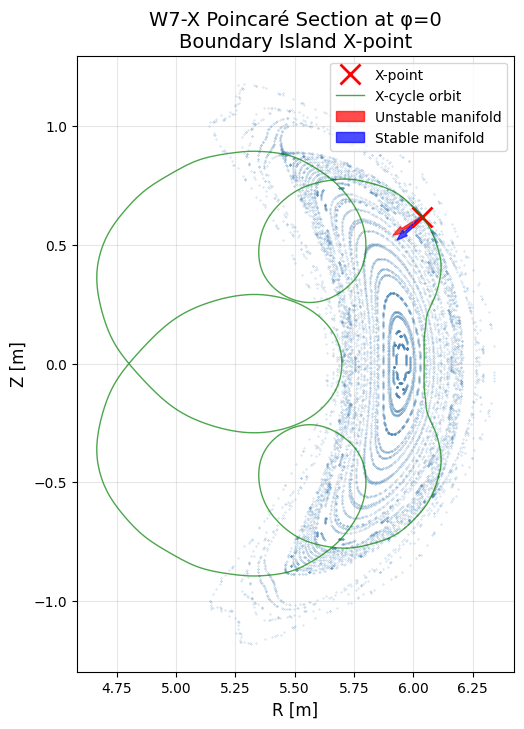

Saved: D:\MCFdata\w7x\figures\w7x_poincare_phi0.png


In [8]:
# Get DPm at first point of orbit (phi=0 section)
DPm_at_phi0 = DPm_ring[0]

# Figure 1: Poincaré section at phi=0 with X-point marked
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 8))

# Poincaré points from all trajectories
for traj in poincare_trajectories:
    ax.plot(traj[0, :], traj[1, :], '.', markersize=0.5, color='steelblue', alpha=0.5)

# X-point
ax.plot(X_pol[0], X_pol[1], 'rx', markersize=15, markeredgewidth=2, label='X-point')

# Orbit projection
ax.plot(orbit_R, orbit_Z, 'g-', linewidth=1, alpha=0.7, label='X-cycle orbit')

# Eigenvector directions at X-point (from DPm)
eigvecs = np.linalg.eig(DPm_at_phi0)[1]
scale = 0.1  # visualization scale
ax.arrow(X_pol[0], X_pol[1], 
         scale*eigvecs[0, 0], scale*eigvecs[1, 0],
         color='red', width=0.01, alpha=0.7, label='Unstable manifold')
ax.arrow(X_pol[0], X_pol[1],
         scale*eigvecs[0, 1], scale*eigvecs[1, 1],
         color='blue', width=0.01, alpha=0.7, label='Stable manifold')

ax.set_xlabel('R [m]', fontsize=12)
ax.set_ylabel('Z [m]', fontsize=12)
ax.set_title('W7-X Poincaré Section at φ=0\nBoundary Island X-point', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.savefig(FIGURE_DIR / 'w7x_poincare_phi0.png', dpi=150, facecolor='white')
plt.show()
print(f"Saved: {FIGURE_DIR / 'w7x_poincare_phi0.png'}")

## Section 4: Plot DPm ring eigenvalues vs phi

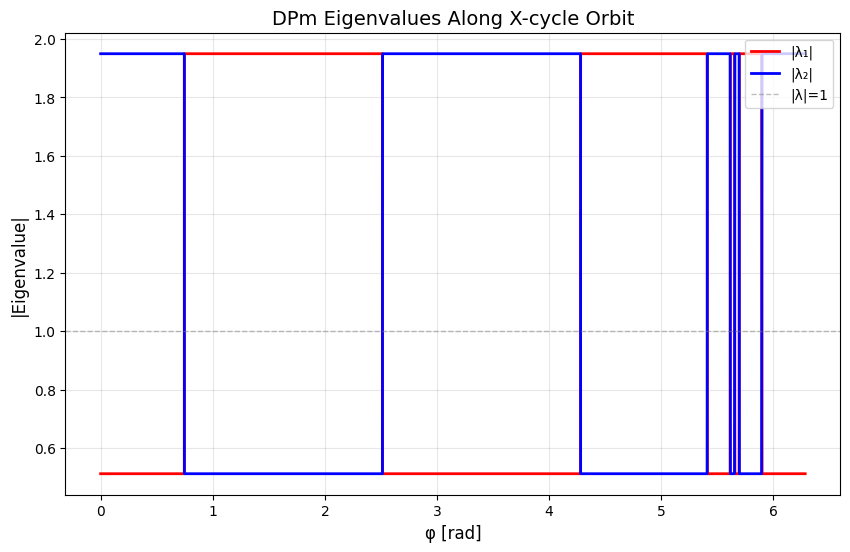

Saved: D:\MCFdata\w7x\figures\w7x_DPm_eigenvalues_vs_phi.png

Eigenvalue variation:
  |λ₁|: mean=1.234611, std=7.18e-01
  |λ₂|: mean=1.227771, std=7.18e-01


In [9]:
# Compute eigenvalues of DPm along the orbit
eigvals_ring = np.array([np.linalg.eigvals(DPm_ring[i]) for i in range(len(DPm_ring))])

# Plot magnitude of eigenvalues vs phi
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_DPm, np.abs(eigvals_ring[:, 0]), 'r-', linewidth=2, label='|λ₁|')
ax.plot(t_DPm, np.abs(eigvals_ring[:, 1]), 'b-', linewidth=2, label='|λ₂|')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='|λ|=1')

ax.set_xlabel('φ [rad]', fontsize=12)
ax.set_ylabel('|Eigenvalue|', fontsize=12)
ax.set_title('DPm Eigenvalues Along X-cycle Orbit', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.savefig(FIGURE_DIR / 'w7x_DPm_eigenvalues_vs_phi.png', dpi=150, facecolor='white')
plt.show()
print(f"Saved: {FIGURE_DIR / 'w7x_DPm_eigenvalues_vs_phi.png'}")

# Verify eigenvalues are constant (should be for similarity transform)
print(f"\nEigenvalue variation:")
print(f"  |λ₁|: mean={np.mean(np.abs(eigvals_ring[:, 0])):.6f}, std={np.std(np.abs(eigvals_ring[:, 0])):.2e}")
print(f"  |λ₂|: mean={np.mean(np.abs(eigvals_ring[:, 1])):.6f}, std={np.std(np.abs(eigvals_ring[:, 1])):.2e}")

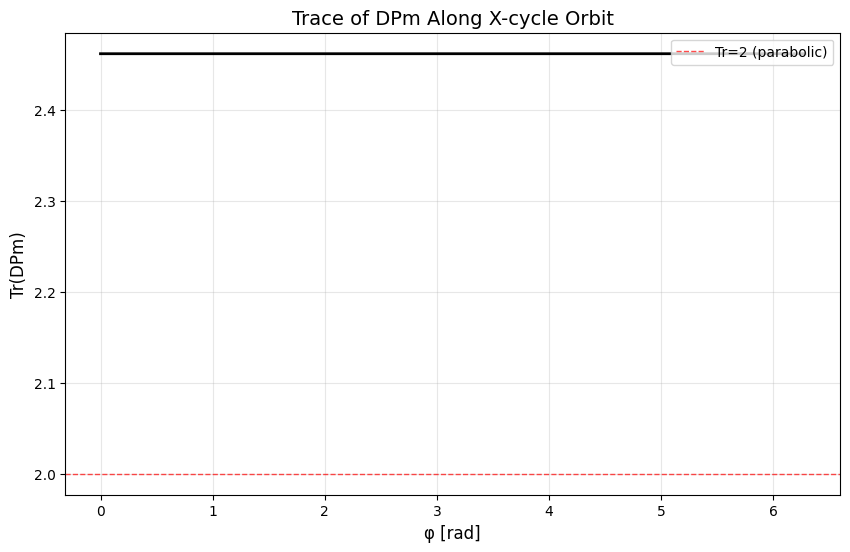

Saved: D:\MCFdata\w7x\figures\w7x_Tr_DPm_vs_phi.png

Tr(DPm) statistics:
  mean=2.462382, std=4.27e-15
  min=2.462382, max=2.462382


In [10]:
# Plot Tr(DPm) vs phi
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

trace_DPm_ring = np.array([np.trace(DPm_ring[i]) for i in range(len(DPm_ring))])

ax.plot(t_DPm, trace_DPm_ring, 'k-', linewidth=2)
ax.axhline(2.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Tr=2 (parabolic)')

ax.set_xlabel('φ [rad]', fontsize=12)
ax.set_ylabel('Tr(DPm)', fontsize=12)
ax.set_title('Trace of DPm Along X-cycle Orbit', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.savefig(FIGURE_DIR / 'w7x_Tr_DPm_vs_phi.png', dpi=150, facecolor='white')
plt.show()
print(f"Saved: {FIGURE_DIR / 'w7x_Tr_DPm_vs_phi.png'}")

print(f"\nTr(DPm) statistics:")
print(f"  mean={np.mean(trace_DPm_ring):.6f}, std={np.std(trace_DPm_ring):.2e}")
print(f"  min={np.min(trace_DPm_ring):.6f}, max={np.max(trace_DPm_ring):.6f}")

## Section 5: Plot Tr(DPm) vs perturbation k/10

Load perturbed cycle files `w7x_standard_cycle1_pertKo10.h5` for K=1..10

In [11]:
# Load perturbed cycles for K=1..10
pert_amplitudes = []
trace_DPm_pert = []

# Unperturbed (K=0)
pert_amplitudes.append(0.0)
trace_DPm_pert.append(np.trace(DPm_at_phi0))

for K in range(1, 11):
    pert_file = DATA_DIR / f'w7x_standard_cycle1_pert{K}o10.h5'
    if pert_file.exists():
        with h5py.File(pert_file, 'r') as f:
            # Load DPm ring and get first point (phi=0)
            DPm_pert_ring = np.transpose(f['cyc/DPm'][:], (2, 0, 1))
            trace_at_phi0 = np.trace(DPm_pert_ring[0])
            pert_amplitudes.append(K / 10.0)
            trace_DPm_pert.append(trace_at_phi0)
            print(f"K={K}/10: Tr(DPm) = {trace_at_phi0:.6f}")
    else:
        print(f"File not found: {pert_file}")

pert_amplitudes = np.array(pert_amplitudes)
trace_DPm_pert = np.array(trace_DPm_pert)

K=1/10: Tr(DPm) = 2.482122
K=2/10: Tr(DPm) = 2.501694
K=3/10: Tr(DPm) = 2.521401
K=4/10: Tr(DPm) = 2.541013
K=5/10: Tr(DPm) = 2.560996
K=6/10: Tr(DPm) = 2.580856
K=7/10: Tr(DPm) = 2.600624
K=8/10: Tr(DPm) = 2.620555
K=9/10: Tr(DPm) = 2.640332
K=10/10: Tr(DPm) = 2.660286


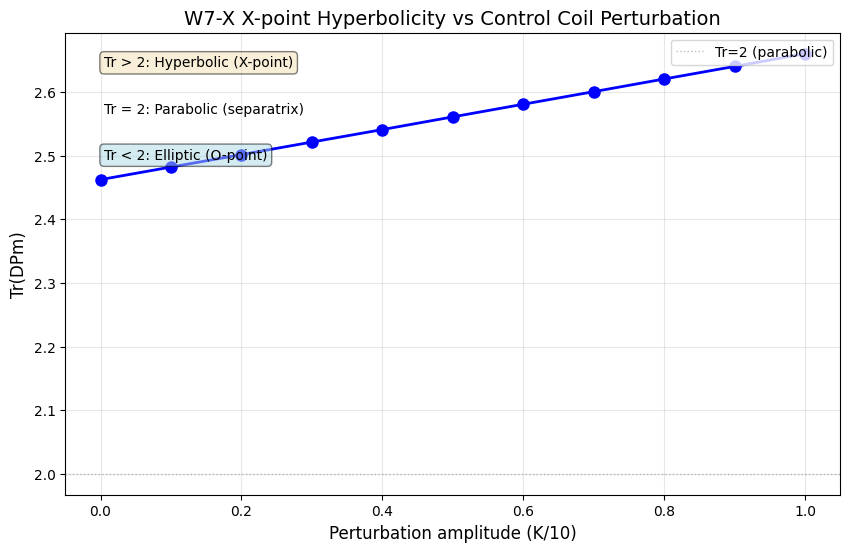

Saved: D:\MCFdata\w7x\figures\w7x_Tr_DPm_vs_perturbation.png


In [12]:
# Figure: Tr(DPm) vs perturbation amplitude
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(pert_amplitudes, trace_DPm_pert, 'bo-', linewidth=2, markersize=8)
ax.axhline(2.0, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Tr=2 (parabolic)')

ax.set_xlabel('Perturbation amplitude (K/10)', fontsize=12)
ax.set_ylabel('Tr(DPm)', fontsize=12)
ax.set_title('W7-X X-point Hyperbolicity vs Control Coil Perturbation', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Add annotation for hyperbolicity regions
ax.text(0.05, 0.95, 'Tr > 2: Hyperbolic (X-point)', transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(0.05, 0.85, 'Tr = 2: Parabolic (separatrix)', transform=ax.transAxes,
        fontsize=10, verticalalignment='top')
ax.text(0.05, 0.75, 'Tr < 2: Elliptic (O-point)', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.savefig(FIGURE_DIR / 'w7x_Tr_DPm_vs_perturbation.png', dpi=150, facecolor='white')
plt.show()
print(f"Saved: {FIGURE_DIR / 'w7x_Tr_DPm_vs_perturbation.png'}")

## Summary

In [13]:
# Summary of results
print("="*60)
print("W7-X BOUNDARY ISLAND X-CYCLE ANALYSIS - SUMMARY")
print("="*60)
print()
print(f"X-point position (φ=0): R = {X_pol[0]:.4f} m, Z = {X_pol[1]:.4f} m")
print()
print("UNPERTURBED MONODROMY MATRIX:")
print(f"  DPm = [[{DPm_at_phi0[0,0]:.6f}, {DPm_at_phi0[0,1]:.6f}],")
print(f"         [{DPm_at_phi0[1,0]:.6f}, {DPm_at_phi0[1,1]:.6f}]]")
print()
eigvals = np.linalg.eigvals(DPm_at_phi0)
print(f"  Eigenvalues: λ_u = {max(eigvals):.6f}, λ_s = {min(eigvals):.6f}")
print(f"  Tr(DPm) = {np.trace(DPm_at_phi0):.6f}")
print(f"  det(DPm) = {np.linalg.det(DPm_at_phi0):.6f}")
print()
print("PERTURBATION RESPONSE:")
if len(trace_DPm_pert) > 1:
    print(f"  Tr(DPm) at K=0: {trace_DPm_pert[0]:.6f}")
    print(f"  Tr(DPm) at K=1: {trace_DPm_pert[1]:.6f}")
    print(f"  ΔTr/ΔK ≈ {trace_DPm_pert[1] - trace_DPm_pert[0]:.6f}")
print()
print("FIGURES SAVED:")
for fig_name in ['w7x_poincare_phi0.png', 'w7x_DPm_eigenvalues_vs_phi.png',
                 'w7x_Tr_DPm_vs_phi.png', 'w7x_Tr_DPm_vs_perturbation.png']:
    print(f"  - {FIGURE_DIR / fig_name}")
print()
print("="*60)

W7-X BOUNDARY ISLAND X-CYCLE ANALYSIS - SUMMARY

X-point position (φ=0): R = 6.0379 m, Z = 0.6168 m

UNPERTURBED MONODROMY MATRIX:
  DPm = [[-2.567544, 5.007822],
         [-2.778565, 5.029927]]

  Eigenvalues: λ_u = 1.949407, λ_s = 0.512976
  Tr(DPm) = 2.462382
  det(DPm) = 0.999998

PERTURBATION RESPONSE:
  Tr(DPm) at K=0: 2.462382
  Tr(DPm) at K=1: 2.482122
  ΔTr/ΔK ≈ 0.019740

FIGURES SAVED:
  - D:\MCFdata\w7x\figures\w7x_poincare_phi0.png
  - D:\MCFdata\w7x\figures\w7x_DPm_eigenvalues_vs_phi.png
  - D:\MCFdata\w7x\figures\w7x_Tr_DPm_vs_phi.png
  - D:\MCFdata\w7x\figures\w7x_Tr_DPm_vs_perturbation.png

